### Imports

In [1]:
import pandas as pd
import numpy as np
import joblib
import xgboost as xgb

from pathlib import Path
from sklearn.model_selection import GridSearchCV
from sklearn.pipeline import Pipeline
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

### Loading Assets

In [2]:
path = Path("../models/preprocessor.pkl")
pre = joblib.load(path)
X_train = pd.read_csv("../data/processed/X_train.csv")
X_test = pd.read_csv("../data/processed/X_test.csv")
y_train_sales = pd.read_csv("../data/processed/y_train_sales.csv").squeeze("columns")
y_test_sales = pd.read_csv("../data/processed/y_test_sales.csv").squeeze("columns")
y_train_profit = pd.read_csv("../data/processed/y_train_profit.csv").squeeze("columns")
y_test_profit = pd.read_csv("../data/processed/y_test_profit.csv").squeeze("columns")


### Evaluation function

In [3]:
def eval_model(name, est, X_train, y_train, X_test, y_test):
    model = Pipeline([("pre", pre), ("est", est)])
    model.fit(X_train, y_train)
    y_pred = model.predict(X_test)
    mae  = mean_absolute_error(y_test, y_pred)
    rmse = np.sqrt(mean_squared_error(y_test, y_pred))
    r2   = r2_score(y_test, y_pred)
    joblib.dump(model, f"../models/{name}.pkl")
    return {"name": name, "MAE": mae, "RMSE": rmse, "R2": r2}, model

### Hyperparameters

In [4]:
est = xgb.XGBRegressor(
    n_estimators=800,
    max_depth=8,
    learning_rate=0.05,
    subsample=0.8,
    colsample_bytree=0.8,
    reg_lambda=1.0,
    random_state=42,
    n_jobs=-1
)

In [5]:
xgb_sales = eval_model("sales_xgb", est, X_train, y_train_sales, X_test, y_test_sales)
xgb_profit = eval_model("profit_xgb", est, X_train, y_train_profit, X_test, y_test_profit)

### Gridsearch on sales

In [6]:
grid = {
    "est__n_estimators": [600,1000],
    "est__max_depth": [6,8,10],
    "est__learning_rate": [0.03, 0.05, 0.1],
    "est__subsample": [0.8, 1.0]
}
search = GridSearchCV(Pipeline([
        ("pre", pre), 
        ("est", xgb.XGBRegressor(random_state=42, n_jobs=-1))]),
                param_grid=grid,
                cv=3,
                n_jobs=-1,
                scoring="neg_mean_absolute_error",
                verbose=2
                )

search.fit(X_train, y_train_sales)


Fitting 3 folds for each of 36 candidates, totalling 108 fits


,estimator,"Pipeline(step...=None, ...))])"
,param_grid,"{'est__learning_rate': [0.03, 0.05, ...], 'est__max_depth': [6, 8, ...], 'est__n_estimators': [600, 1000], 'est__subsample': [0.8, 1.0]}"
,scoring,'neg_mean_absolute_error'
,n_jobs,-1
,refit,True
,cv,3
,verbose,2
,pre_dispatch,'2*n_jobs'
,error_score,nan
,return_train_score,False
,transformers,"[('num', ...), ('cat', ...)]"


In [7]:
best_model = search.best_estimator_

In [8]:
y_pred = best_model.predict(X_test)

In [9]:
metrics_sales = {
    "name":"sales_xgb_best",
    "MAE": mean_absolute_error(y_test_sales, y_pred),
    "MSE": mean_squared_error(y_test_sales, y_pred),
    "RMSE": np.sqrt(mean_squared_error(y_test_sales, y_pred)),
    "R2": r2_score(y_test_sales, y_pred)
}
print(metrics_sales)

{'name': 'sales_xgb_best', 'MAE': 216.04871590719335, 'MSE': 188413.9560828776, 'RMSE': np.float64(434.0667645453607), 'R2': 0.3851124175973262}


In [10]:
joblib.dump(best_model, "../models/sales_xgb_best.pkl")

['../models/sales_xgb_best.pkl']

### Gridsearch on profit

In [11]:
search.fit(X_train, y_train_profit)
best_profit = search.best_estimator_
yp = best_profit.predict(X_test)

Fitting 3 folds for each of 36 candidates, totalling 108 fits


In [12]:
joblib.dump(best_profit, "../models/profit_xgb_best.pkl")

['../models/profit_xgb_best.pkl']

In [13]:
metrics_profit = {
    "name":"profit_xgb_best",
    "MAE": mean_absolute_error(y_test_profit, yp),
    "MSE": mean_squared_error(y_test_profit, yp),
    "RMSE": np.sqrt(mean_squared_error(y_test_profit, yp)),
    "R2": r2_score(y_test_profit, yp)
}

In [14]:
print(metrics_profit)

{'name': 'profit_xgb_best', 'MAE': 47.95912926047283, 'MSE': 8490.274223410204, 'RMSE': np.float64(92.14268404713532), 'R2': 0.5253660279097874}


### Saving results

In [15]:
pd.DataFrame([metrics_sales, metrics_profit]).to_csv("../reports/xgb_metrics.csv", index=False)

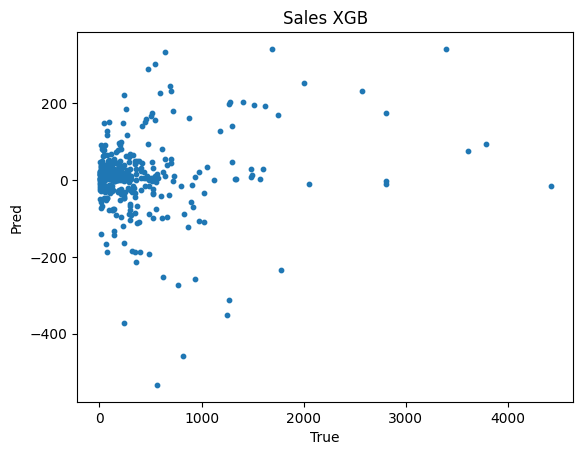

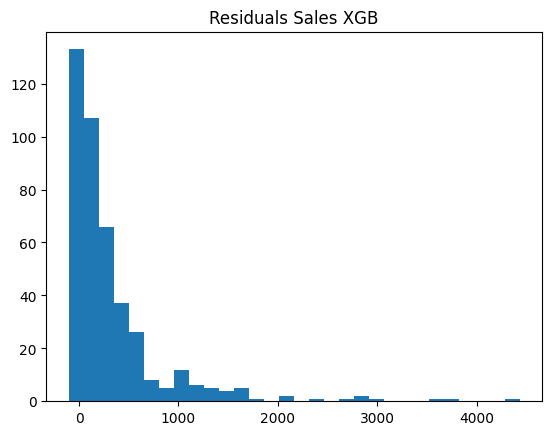

In [16]:
import matplotlib.pyplot as plt
plt.scatter(y_test_sales, search.best_estimator_.predict(X_test), s=10)
plt.xlabel("True"); plt.ylabel("Pred"); plt.title("Sales XGB"); plt.show()
res = y_test_sales - search.best_estimator_.predict(X_test)
plt.hist(res, bins=30); plt.title("Residuals Sales XGB"); plt.show()


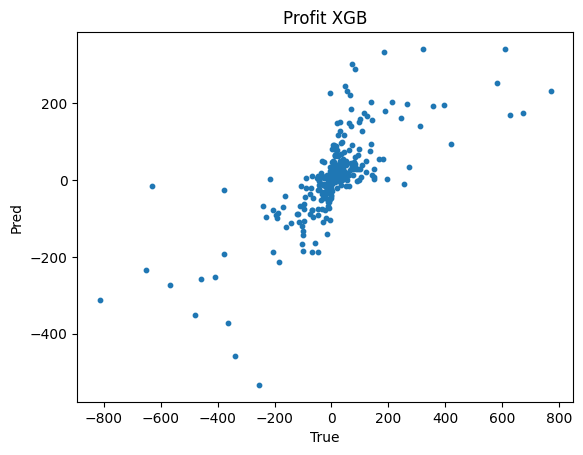

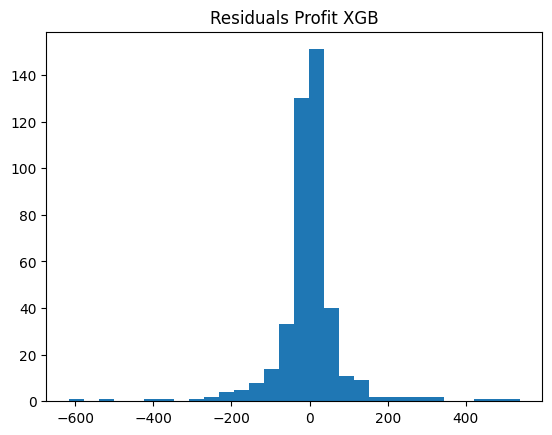

In [17]:
import matplotlib.pyplot as plt
plt.scatter(y_test_profit, best_profit.predict(X_test), s=10)
plt.xlabel("True"); plt.ylabel("Pred"); plt.title("Profit XGB"); plt.show()
res = y_test_profit - best_profit.predict(X_test)
plt.hist(res, bins=30); plt.title("Residuals Profit XGB"); plt.show()
